# Analyzing Titanic Passenger Data

## Standard imports

In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## Read data from spreadsheet
Pandas' .read_excel() method will load data from a spreadsheet. 

Note that, in a notebook, if the last line in a cell is an expression (not an assignment), it will be displayed as output.

In [2]:
import os
os.getcwd()

'/Users/jstrick/curr/courses/python/common/notebooks'

In [3]:

df = pd.read_excel('../DATA/titanic3.xls')


In [4]:
df.describe(include='all')

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
count,1309.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307,486,121.000000,745
unique,NaN,NaN,1307,2,NaN,NaN,NaN,939,NaN,186,3,28,NaN,369
top,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,2.294882,0.381971,NaN,NaN,29.881135,0.498854,0.385027,NaN,33.295479,NaN,NaN,NaN,160.809917,NaN
std,0.837836,0.486055,NaN,NaN,14.413500,1.041658,0.865560,NaN,51.758668,NaN,NaN,NaN,97.696922,NaN
min,1.000000,0.000000,NaN,NaN,0.166700,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,2.000000,0.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN
50%,3.000000,0.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN
75%,3.000000,1.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN


In [5]:
df.memory_usage(deep=True)

Index           132
pclass        10472
survived      10472
name         110127
sex           80781
age           10472
sibsp         10472
parch         10472
ticket        81676
fare          10472
cabin         50366
embarked      75870
boat          54738
body          10472
home.dest     74791
dtype: int64

In [6]:
df = df.astype({'sex': 'category', 'embarked': 'category'})
df.memory_usage(deep=True)

Index           132
pclass        10472
survived      10472
name         110127
sex            1541
age           10472
sibsp         10472
parch         10472
ticket        81676
fare          10472
cabin         50366
embarked       1591
boat          54738
body          10472
home.dest     74791
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   int64   
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(2), float64(3), int64(4), object(5)
memory usage: 125.7+ KB


In [8]:
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

Text(1, 900, '500')

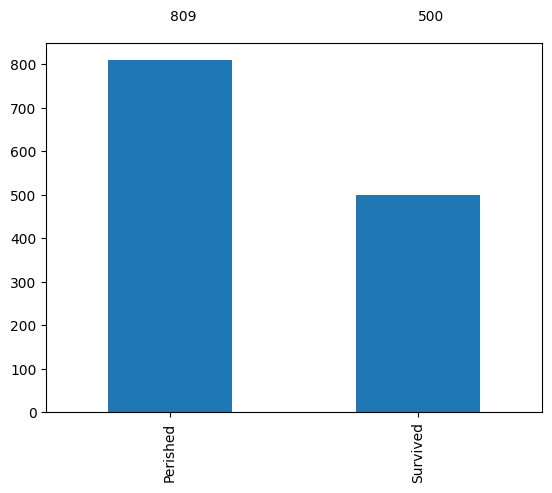

In [9]:
survival = df['survived'].value_counts()
survival.index = ['Perished', 'Survived']
survival.plot(kind='bar')
ax = plt.gca()
plt.text(0,900, survival['Perished'])
plt.text(1,900, survival['Survived'])


sex
male      843
female    466
Name: count, dtype: int64


Text(1, 900, '466')

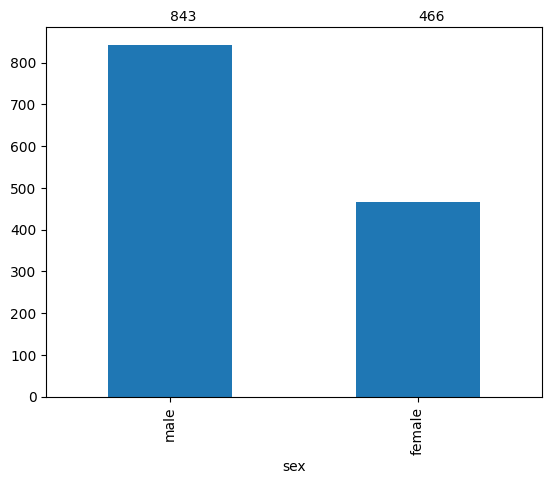

In [10]:
passengers_by_sex = df['sex'].value_counts()
print(passengers_by_sex)
passengers_by_sex.plot(kind='bar')
ax = plt.gca()
plt.text(0,900, passengers_by_sex['male'])
plt.text(1,900, passengers_by_sex['female'])



## The .query() method

The *query* method lets you query a dataframe in a similar to way to querying a database table. 

In [11]:
df[['pclass', 'survived', 'sex', 'age']].query(
    'sex == "female" and survived == 1 and pclass == 1 and 45 <= age <= 60'
).sort_values(by="age", ascending=False)

,pclass,survived,sex,age
43,1,1,female,60.0
116,1,1,female,60.0
304,1,1,female,60.0
42,1,1,female,59.0
33,1,1,female,58.0
139,1,1,female,58.0
50,1,1,female,58.0
192,1,1,female,58.0
233,1,1,female,56.0
186,1,1,female,55.0


## Without the .query() method

Without the .query() method, it is much less readable to do the same selection. 

In [12]:
df[['pclass', 'survived', 'sex', 'age']][
    df['sex'] == "female"][df['pclass'] == 1][df['survived'] == 1
][df['age'] >= 45][df['age'] <= 60].sort_values(by="age", ascending=False)

,pclass,survived,sex,age
43,1,1,female,60.0
116,1,1,female,60.0
304,1,1,female,60.0
42,1,1,female,59.0
33,1,1,female,58.0
139,1,1,female,58.0
50,1,1,female,58.0
192,1,1,female,58.0
233,1,1,female,56.0
186,1,1,female,55.0


## Dropping N/A values

The .dropna() method will remove values of NaN from rows or columns.

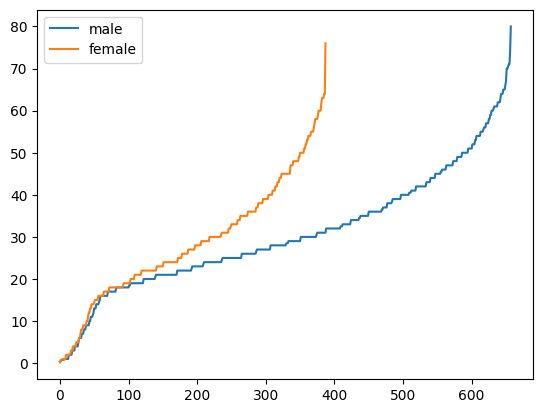

In [13]:
age_data = {}
for sex in ['male', 'female']:
    age_data[sex] = df.query('sex  == @sex')['age'].dropna()
    age_data[sex].sort_values(inplace=True)
#     print(label.upper())
#     print(age_data[sex].head(20))
    plt.plot(range(len(age_data[sex])), age_data[sex].values, label=sex)
plt.ylabel = "age"
plt.xlabel = "number of people"
plt.legend()


## Getting Dummy (1-Hot) Values

The __get_dummies()__ function will turn a categorical column (strings with low cardinality) into multiple columns, one for each distinct value in the column. The new columns will have the value one for each row which has that value. 

In [14]:
dummies = pd.get_dummies(df.loc[:, 'sex'])
dummies.head()

,female,male
0,True,False
1,False,True
2,True,False
3,False,True
4,True,False


Now we can merge the dummy variables into the original dataframe

In [15]:
df_hot = pd.merge(df, dummies, left_index=True, right_index=True)
df_hot

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,female,male
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",True,False
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",False,True
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",True,False
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",False,True
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,True,False
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,True,False
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,False,True
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,False,True


In [16]:
df_hot[(df_hot['female'] == 1) & (df_hot['survived'] == 1)]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,female,male
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",True,False
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY",True,False
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY",True,False
11,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,0,PC 17757,227.5250,C62 C64,C,4,NaN,"New York, NY",True,False
12,1,1,"Aubart, Mme. Leontine Pauline",female,24.0,0,0,PC 17477,69.3000,B35,C,9,NaN,"Paris, France",True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260,3,1,"Turja, Miss. Anna Sofia",female,18.0,0,0,4138,9.8417,NaN,S,15,NaN,NaN,True,False
1261,3,1,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S,15,NaN,NaN,True,False
1286,3,1,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,0,0,2688,7.2292,NaN,C,C,NaN,NaN,True,False
1290,3,1,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN,NaN,NaN,True,False


In [17]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [18]:
ab = pd.read_csv("../DATA/airport_boardings.csv", thousands=",", index_col=1)
ab

,Airport,2001 Rank,2001 Total,2010 Rank,2010 Total,2011 Rank,Total,Percent change 2001-2011,Percent change 2010-2011
Code,,,,,,,,,
ATL,"Atlanta, GA (Hartsfield-Jackson Atlanta Intern...",1,36384264,1,42655392,1,33034788,-9.2,-22.6
ORD,"Chicago, IL (Chicago O'Hare International)",2,28626694,2,30033313,2,22367052,-21.9,-25.5
DFW,"Dallas, TX (Dallas/Fort Worth International)",3,25198256,3,26785739,3,20430281,-18.9,-23.7
DEN,"Denver, CO (Denver International)",6,16397390,4,24965553,4,19190341,17.0,-23.1
LAX,"Los Angeles, CA (Los Angeles International)",4,22873307,5,22860849,5,18379418,-19.6,-19.6
PHX,"Phoenix, AZ (Phoenix Sky Harbor International)",5,16540686,7,18657891,6,14680444,-11.2,-21.3
CLT,"Charlotte, NC (Charlotte Douglas International)",19,10226010,8,18539589,7,14207015,38.9,-23.4
LAS,"Las Vegas, NV (McCarran International)",7,16121009,9,17851932,8,13929834,-13.6,-22.0
IAH,"Houston, TX (George Bush Intercontinental)",9,15639781,6,18726696,9,13920435,-11.0,-25.7
